# 01 — Exploratory Data Analysis
### Olist Brazilian E-Commerce · `retail-platform-analytics`

This notebook is the **exploratory foundation** for the project. It profiles the analytics marts
built with dbt on Snowflake, surfaces the main trends and patterns in the data, and ends with a
prioritised **analysis backlog** — the deeper analyses worth building next.

**How to read this notebook**
- Every claim is backed by a query against the marts — no assertions without data.
- Each section states the *question*, runs the query, charts it, then interprets the result.
- Jargon is defined inline the first time it appears.
- Where the data is thin or an assumption matters, I flag it explicitly as a **⚠️ Confidence note**.

**Data source:** `RETAIL_ANALYTICS.DEV_MARTS` (Snowflake) — the mart layer produced by dbt
(`dim_*`, `fct_*`, `mart_*`). Connection is handled by `db.py`, which reads credentials
from the gitignored `.env`.

## Data caveats & conventions

Read these before the analysis — they qualify every number that follows.

- **Reliable window = Jan 2017 – Aug 2018.** The dataset nominally spans Sep 2016 – Oct 2018, but the
  edge months (**Sep–Dec 2016** and **Sep–Oct 2018**) contain only a handful of orders each — they are
  data-collection ramp-in/cutoff artefacts, **not** real demand. Any trend, YoY, or "latest period"
  metric must exclude them or it will report a fake collapse. Quarterly views here show the partial
  edge quarters but flag them.
- **`customer_id` resolution affects the repeat rate.** Olist's raw `customer_id` is *per-order*; the
  stable person is `customer_unique_id`. The ~3% repeat rate (Section 10) is only as accurate as the
  dbt de-duplication — treat it as directional until the mapping is confirmed.
- **Data-quality issues are handled upstream in dbt** (the intermediate layer), not here: duplicate
  `review_id`s, out-of-order delivery timestamps, and incomplete/mismatched payment rows are flagged
  or de-duplicated in `int_*` models. This notebook reads the cleaned marts.
- **No cost data.** Olist provides price and freight but no product cost, so true margin is not
  computable. Where "margin" is discussed we use freight-as-a-share-of-price as an explicit *proxy*.
- **Convention:** every query goes through `q()` (lowercases Snowflake's uppercase columns); revenue =
  `total_payment_value` on `fct_orders` unless stated; charts render inline so the notebook is
  self-contained.

## 1. Setup

We connect to Snowflake through the shared `db.py` helper. `q()` wraps it and lowercases column
names (Snowflake returns them uppercase) so the analysis code stays readable.

In [1]:
import sys
sys.path.insert(0, ".")  # db.py lives in the notebooks/ folder (this notebook's directory)

import db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    """Run SQL against Snowflake and return a DataFrame with lowercase columns."""
    df = db.query(sql)
    df.columns = df.columns.str.lower()
    return df

print("Connected:")
print(q("select current_database() as db, current_schema() as schema, current_warehouse() as wh").to_string(index=False))

Connected:


              db    schema         wh
RETAIL_ANALYTICS DEV_MARTS COMPUTE_WH


## 2. The data landscape — what we are working with

Before analysing anything, we establish the *grain* of each mart (what one row represents) and the
*coverage* (how much data, over what period). This frames every number that follows.

In [2]:
landscape = q('''
    select table_name, row_count
    from retail_analytics.information_schema.tables
    where table_schema = 'DEV_MARTS'
    order by row_count desc nulls last
''')
landscape

,table_name,row_count
0,FCT_ORDER_ITEMS,112650
1,FCT_ORDERS,99441
2,DIM_CUSTOMERS,96096
3,MART_CUSTOMER_SUMMARY,96096
4,DIM_PRODUCTS,32951
5,DIM_GEOLOCATION,19015
6,MART_SELLER_PERFORMANCE,3095
7,DIM_SELLERS,3095


**Grain of the key marts** (one row is…):

| Mart | Grain | Use |
|---|---|---|
| `fct_orders` | one **order** | order-level facts: status, delivery, payment, review |
| `fct_order_items` | one **line item** | product/seller economics: price, freight |
| `dim_customers` / `dim_sellers` / `dim_products` | one entity | descriptive attributes |
| `mart_customer_summary` | one **customer** | pre-aggregated spend/behaviour |
| `mart_seller_performance` | one **seller** | pre-aggregated revenue/quality |

In [3]:
coverage = q('''
    select min(purchased_at)::date as first_order,
           max(purchased_at)::date as last_order,
           count(*)                 as orders,
           count(distinct customer_id) as customers
    from dev_marts.fct_orders
''')
coverage

,first_order,last_order,orders,customers
0,2016-09-04,2018-10-17,99441,96096


**⚠️ Confidence note — partial months at the edges.** The nominal range is Sep 2016 → Oct 2018,
but as the revenue trend (Section 4) shows, **Sep–Dec 2016 and Sep–Oct 2018 are only partially
populated** (a handful of orders each). Treat those months as data-collection artefacts, not real
demand. The reliable analysis window is **Jan 2017 → Aug 2018**.

## 3. Where do orders end up? (Order status)

`status` records the terminal state of each order. This tells us how clean the dataset is and how
much of it represents completed commerce.

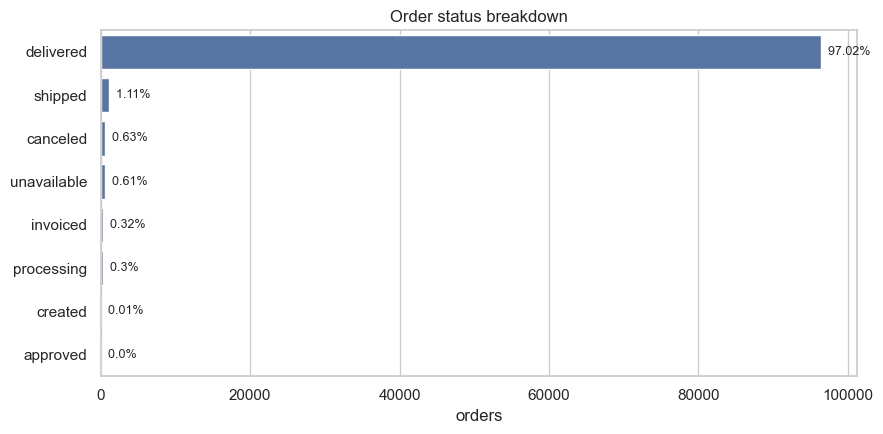

,status,orders,pct
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [4]:
status = q('''
    select status, count(*) as orders
    from dev_marts.fct_orders
    group by 1 order by 2 desc
''')
status["pct"] = (100 * status["orders"] / status["orders"].sum()).round(2)

fig, ax = plt.subplots()
sns.barplot(data=status, y="status", x="orders", ax=ax, color="#4C72B0")
ax.set_title("Order status breakdown")
ax.set_xlabel("orders"); ax.set_ylabel("")
for i, r in status.iterrows():
    ax.text(r["orders"], i, f"  {r['pct']}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()
status

**Interpretation.** ~**97% of orders are `delivered`** — the dataset is overwhelmingly completed
commerce, so order-level revenue and delivery analysis is trustworthy. Non-terminal states
(`shipped`, `processing`, `invoiced`) and `canceled`/`unavailable` together are only ~3.5%. Because
delivered orders so dominate, delivery-quality metrics below are computed on `status = 'delivered'`
to avoid mixing in orders that never completed.

## 4. Revenue & order volume over time

Monthly totals of order count and payment value. This is the single most important context chart —
it reveals the platform's growth trajectory *and* the data-coverage caveats.

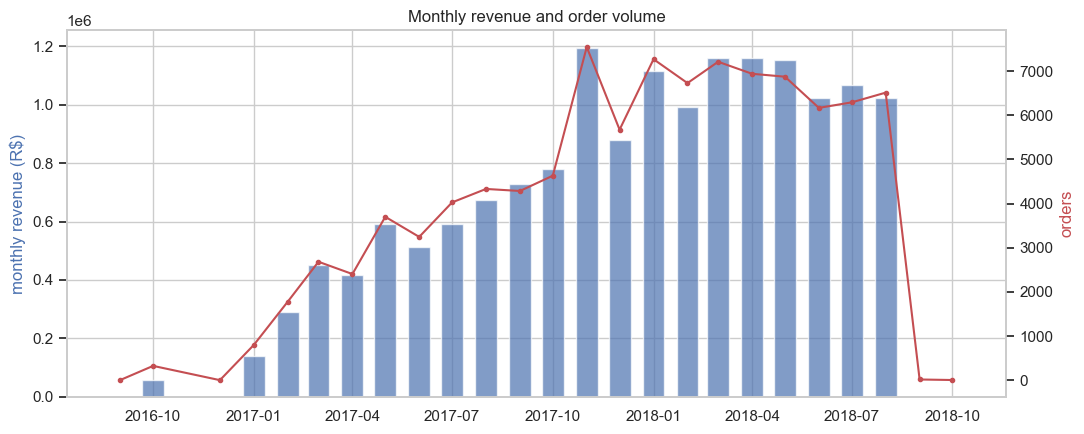

,month,orders,revenue
19,2018-05-01,6873,"1,153,982.15"
20,2018-06-01,6167,"1,023,880.50"
21,2018-07-01,6292,"1,066,540.75"
22,2018-08-01,6512,"1,022,425.32"
23,2018-09-01,16,"4,439.54"
24,2018-10-01,4,589.67


In [5]:
monthly = q('''
    select date_trunc('month', purchased_at)::date as month,
           count(*) as orders,
           sum(total_payment_value) as revenue
    from dev_marts.fct_orders
    group by 1 order by 1
''')

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(monthly["month"], monthly["revenue"], width=20, color="#4C72B0", alpha=0.7, label="revenue")
ax1.set_ylabel("monthly revenue (R$)", color="#4C72B0")
ax1.set_title("Monthly revenue and order volume")
ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["orders"], color="#C44E52", marker="o", ms=3, label="orders")
ax2.set_ylabel("orders", color="#C44E52")
ax2.grid(False)
plt.tight_layout(); plt.show()
monthly.tail(6)

**Interpretation.**
- **Strong growth** through 2017 into mid-2018 — the platform roughly quadrupled monthly volume from
  early 2017 (~800 orders) to a steady ~6,500–7,500 orders/month in 2018.
- A visible **spike in Nov 2017** (7,544 orders, the single biggest month) — Brazil's **Black Friday**.
- The apparent **collapse in Sep–Oct 2018 is not a real decline** — those months have 16 and 4 orders
  respectively. It is the **data cutoff**. Same story for the Sep–Dec 2016 ramp-in.

**⚠️ Confidence note.** Any year-over-year or "latest month" metric must exclude these partial edges,
or it will report a catastrophic fake drop. All trend claims here use **Jan 2017 – Aug 2018**.

### Quarterly revenue & quarter-on-quarter (QoQ) growth

Aggregating to quarters smooths the monthly noise and lets us read the growth *rate* rather than the
level. **QoQ growth** = percent change in revenue versus the immediately preceding quarter. We exclude
`canceled`/`unavailable` orders (no realised revenue).

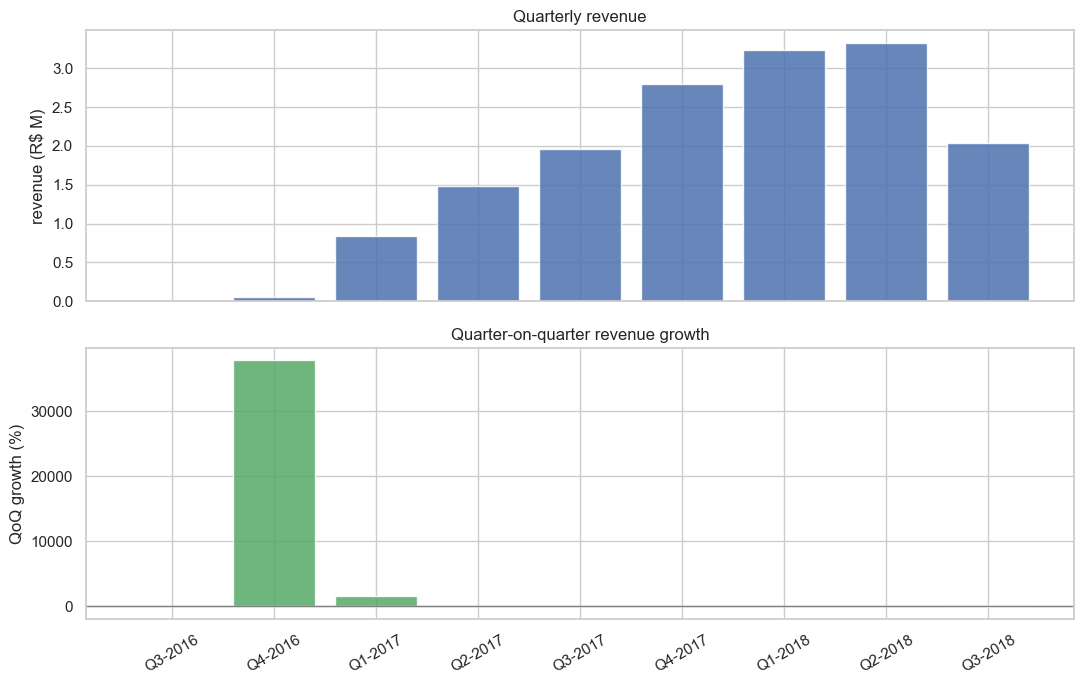

,period,revenue,qoq_growth_pct
0,Q3-2016,136.20,NaN
1,Q4-2016,"51,677.20","37,833.80"
2,Q1-2017,"846,285.10","1,537.60"
3,Q2-2017,"1,488,742.00",75.90
4,Q3-2017,"1,958,125.60",31.50
5,Q4-2017,"2,799,339.00",43.00
6,Q1-2018,"3,235,342.40",15.60
7,Q2-2018,"3,322,546.80",2.70
8,Q3-2018,"2,036,942.80",-38.70


In [6]:
qoq = q('''
    select concat('Q', quarter(purchased_at), '-', year(purchased_at)) as period,
           year(purchased_at) as yr, quarter(purchased_at) as qtr,
           sum(total_payment_value) as revenue
    from dev_marts.fct_orders
    where status not in ('canceled', 'unavailable')
    group by 1, 2, 3 order by 2, 3
''')
qoq["qoq_growth_pct"] = qoq["revenue"].pct_change() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax1.bar(qoq["period"], qoq["revenue"] / 1e6, color="#4C72B0", alpha=0.85)
ax1.set_ylabel("revenue (R$ M)"); ax1.set_title("Quarterly revenue")

g = qoq.dropna(subset=["qoq_growth_pct"])
colors = ["#55A868" if v >= 0 else "#DD8452" for v in g["qoq_growth_pct"]]
ax2.bar(g["period"], g["qoq_growth_pct"], color=colors, alpha=0.85)
ax2.axhline(0, color="grey", lw=1)
ax2.set_ylabel("QoQ growth (%)"); ax2.set_title("Quarter-on-quarter revenue growth")
ax2.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
qoq[["period", "revenue", "qoq_growth_pct"]].round(1)

**Interpretation.** Through the reliable window, growth is strong but **decelerating as the base
matures** — a healthy S-curve: **+76% (Q2-17) → +31% → +43% → +16% (Q1-18) → +2.7% (Q2-18)**. The
last quarter (**Q3-18, −39%**) is *not* a downturn — Q3 only has July + August of real data (September
is the cutoff), so it is mechanically incomplete.

**⚠️ Confidence note.** The first two quarters (2016 Q3–Q4 → 2017 Q1) show absurd growth percentages
(1,500%+) purely because the denominator is near-zero during ramp-in. QoQ % is only meaningful from
**Q2-2017 onward**, and the final quarter is partial. Read the *trend in the rate*, not the edge values.

## 5. Delivery performance

Two questions: *how long* does delivery take, and *how reliable* is it versus the promise shown to
the customer at checkout?

- **`delivery_time_days`** = days from purchase to delivery to the customer.
- **On-time** = delivered on or before `estimated_delivery_date` (the estimate shown at checkout).

In [7]:
deliv = q('''
    select count(*) as delivered,
           avg(delivery_time_days)  as avg_days,
           median(delivery_time_days) as median_days,
           avg(iff(is_delivered_on_time, 1, 0)) * 100 as on_time_pct
    from dev_marts.fct_orders
    where status = 'delivered' and delivery_time_days is not null
''')
deliv

,delivered,avg_days,median_days,on_time_pct
0,96470,12.50,10.00,91.89


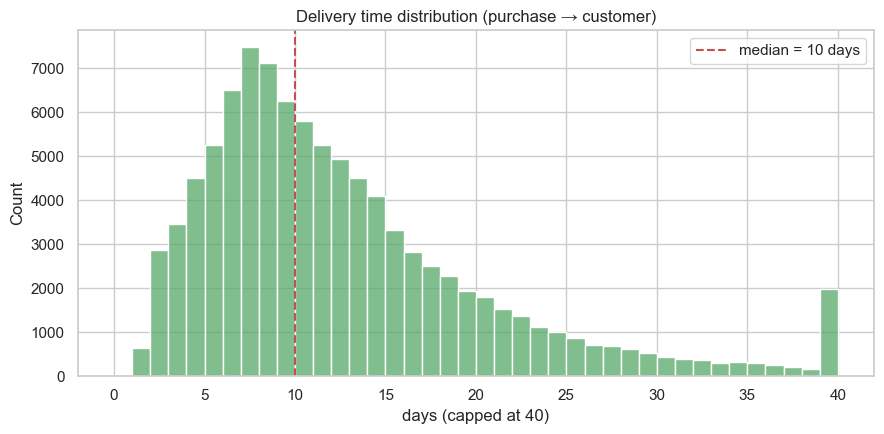

In [8]:
# Distribution of delivery times (capped at 40 days for readability)
dist = q('''
    select least(delivery_time_days, 40) as days
    from dev_marts.fct_orders
    where status = 'delivered' and delivery_time_days between 0 and 200
''')
fig, ax = plt.subplots()
sns.histplot(dist["days"], bins=40, color="#55A868", ax=ax)
ax.axvline(dist["days"].median(), color="#C44E52", ls="--", label=f"median = {dist['days'].median():.0f} days")
ax.set_title("Delivery time distribution (purchase → customer)")
ax.set_xlabel("days (capped at 40)"); ax.legend()
plt.tight_layout(); plt.show()

In [9]:
# How much earlier/later than the promised date do orders actually arrive?
buffer = q('''
    select avg(datediff('day', delivered_to_customer_at, estimated_delivery_date)) as avg_days_early
    from dev_marts.fct_orders
    where status = 'delivered' and delivered_to_customer_at is not null
''')
buffer

,avg_days_early
0,11.88


**Interpretation.**
- Median delivery is **~10 days**, mean **~12.5 days** — the right-skew (a tail of slow deliveries)
  pulls the mean above the median, which is why we report both.
- **~92% of orders arrive on time**, and on average **~12 days *earlier* than the estimated date**.
  This means Olist's checkout estimates are **deliberately conservative** (under-promise, over-deliver).
  That's operationally sensible but it also means the "estimated delivery date" is a soft target, not
  a tight SLA.

## 6. Geographic concentration

Brazil is large and unevenly populated. `delivery_state` is the two-letter state code of the delivery
address (e.g. **SP** = São Paulo, **RJ** = Rio de Janeiro, **MG** = Minas Gerais).

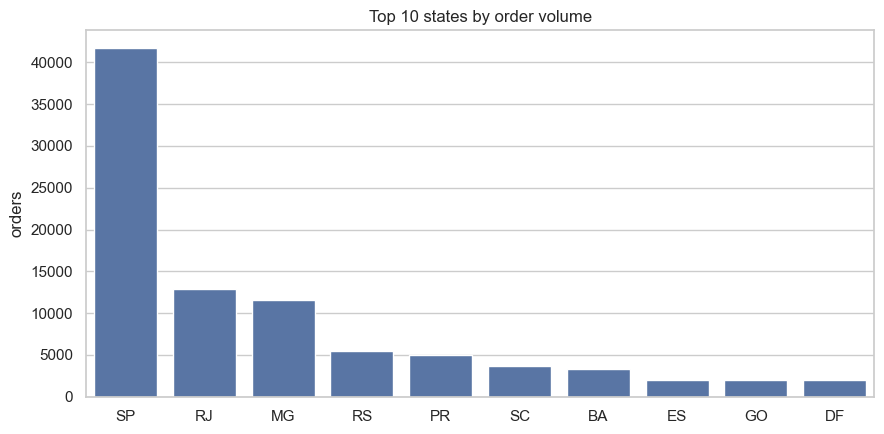

,state,orders,revenue,order_share_pct
0,SP,41731,"5,996,050.41",46.50
1,RJ,12839,"2,142,349.25",14.30
2,MG,11624,"1,871,072.52",13.00
3,RS,5462,"890,584.82",6.10
4,PR,5034,"810,280.15",5.60
5,SC,3637,"623,086.43",4.10
6,BA,3371,"615,203.62",3.80
7,ES,2027,"325,490.67",2.30
8,GO,2011,"349,377.13",2.20
9,DF,1969,"326,095.81",2.20


In [10]:
geo = q('''
    select delivery_state as state, count(*) as orders, sum(total_payment_value) as revenue
    from dev_marts.fct_orders
    group by 1 order by 2 desc limit 10
''')
geo["order_share_pct"] = (100 * geo["orders"] / geo["orders"].sum() ).round(1)

fig, ax = plt.subplots()
sns.barplot(data=geo, x="state", y="orders", ax=ax, color="#4C72B0", order=geo["state"])
ax.set_title("Top 10 states by order volume"); ax.set_xlabel(""); ax.set_ylabel("orders")
plt.tight_layout(); plt.show()
geo

**Interpretation.** Demand is **heavily concentrated in the Southeast**. **São Paulo (SP) alone is
~42% of all orders** and revenue; the top three states (SP, RJ, MG) together are the majority of the
platform. This concentration matters for later analysis: national averages are effectively
*SP averages*, and delivery/logistics performance will be dominated by the Southeast corridor. Any
regional insight should be read against this base-rate skew.

## 7. Product categories & revenue concentration (Pareto)

Which categories drive revenue, and how concentrated is that revenue? The **Pareto principle** ("80/20
rule") predicts that a small share of categories drives most revenue — we test it rather than assume it.

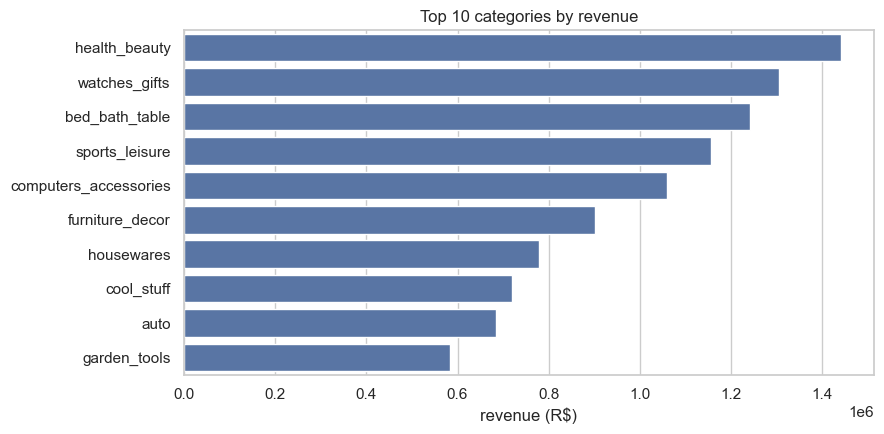

,category_name,revenue,items,pct
0,health_beauty,"1,441,248.07",9670,9.20
1,watches_gifts,"1,305,541.61",5991,8.40
2,bed_bath_table,"1,241,681.72",11115,7.90
3,sports_leisure,"1,156,656.48",8641,7.40
4,computers_accessories,"1,059,272.40",7827,6.80
5,furniture_decor,"902,511.79",8334,5.80
6,housewares,"778,397.77",6964,5.00
7,cool_stuff,"719,329.95",3796,4.60
8,auto,"685,384.32",4235,4.40
9,garden_tools,"584,219.21",4347,3.70


In [11]:
cats = q('''
    select category_name, sum(total_item_value) as revenue, count(*) as items
    from dev_marts.fct_order_items
    where category_name is not null
    group by 1 order by 2 desc
''')
cats["pct"] = (100 * cats["revenue"] / cats["revenue"].sum()).round(1)

fig, ax = plt.subplots()
sns.barplot(data=cats.head(10), y="category_name", x="revenue", ax=ax, color="#4C72B0")
ax.set_title("Top 10 categories by revenue"); ax.set_xlabel("revenue (R$)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
cats.head(10)

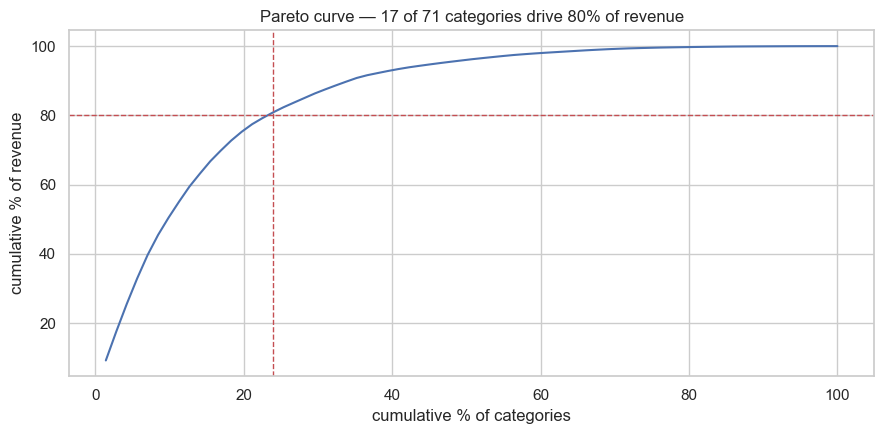

17 categories (24% of 71) = 80% of revenue


In [12]:
# Pareto curve: cumulative revenue share vs cumulative share of categories
cats_sorted = cats.sort_values("revenue", ascending=False).reset_index(drop=True)
cats_sorted["cum_rev_pct"] = 100 * cats_sorted["revenue"].cumsum() / cats_sorted["revenue"].sum()
cats_sorted["cat_rank_pct"] = 100 * (cats_sorted.index + 1) / len(cats_sorted)
n_to_80 = int((cats_sorted["cum_rev_pct"] <= 80).sum()) + 1

fig, ax = plt.subplots()
ax.plot(cats_sorted["cat_rank_pct"], cats_sorted["cum_rev_pct"], color="#4C72B0")
ax.axhline(80, color="#C44E52", ls="--", lw=1)
ax.axvline(100 * n_to_80 / len(cats_sorted), color="#C44E52", ls="--", lw=1)
ax.set_title(f"Pareto curve — {n_to_80} of {len(cats_sorted)} categories drive 80% of revenue")
ax.set_xlabel("cumulative % of categories"); ax.set_ylabel("cumulative % of revenue")
plt.tight_layout(); plt.show()
print(f"{n_to_80} categories ({100*n_to_80/len(cats_sorted):.0f}% of {len(cats_sorted)}) = 80% of revenue")

**Interpretation.** Revenue is **broad, not dominated by one category** — the top category
(`health_beauty`) is only ~9%. But concentration still holds roughly to the 80/20 rule: **~17 of 72
categories (~24%) generate 80% of revenue**, and the long tail of ~55 categories splits the last 20%.
For a marts/BI perspective this means a category dashboard needs the top ~20 broken out and the rest
bucketed as "other".

### Freight as a margin proxy

Olist provides price and freight but **no product-cost data**, so true margin cannot be computed.
**Freight as a share of item price** (`freight ÷ price`) is a usable *proxy* for margin pressure — the
more of each sale consumed by shipping, the thinner the room left for margin. We track it over time to
see whether shipping is eating a growing share of revenue.

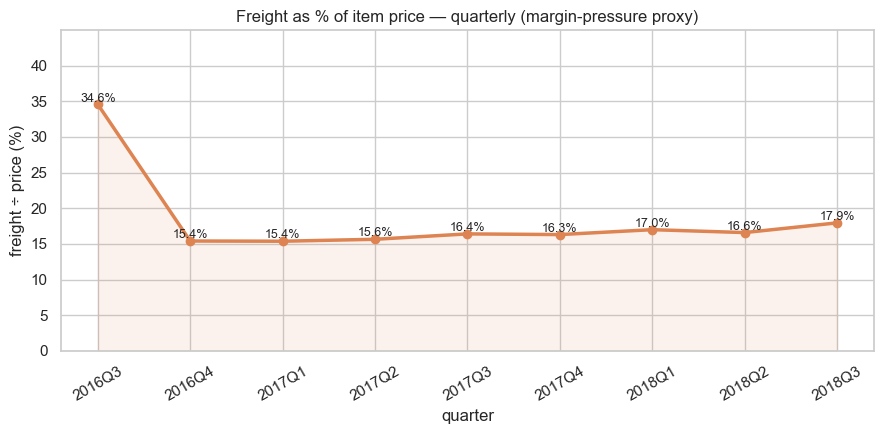

,label,freight_pct
0,2016Q3,34.60
1,2016Q4,15.40
2,2017Q1,15.40
3,2017Q2,15.60
4,2017Q3,16.40
5,2017Q4,16.30
6,2018Q1,17.00
7,2018Q2,16.60
8,2018Q3,17.90


In [13]:
freight_q = q('''
    select date_trunc('quarter', o.purchased_at)::date as quarter,
           sum(i.freight_value) as total_freight,
           sum(i.price)         as total_price,
           100.0 * sum(i.freight_value) / sum(i.price) as freight_pct
    from dev_marts.fct_orders o
    join dev_marts.fct_order_items i on o.order_id = i.order_id
    where o.status not in ('canceled', 'unavailable')
    group by 1 order by 1
''')
freight_q["label"] = pd.to_datetime(freight_q["quarter"]).dt.to_period("Q").astype(str)

fig, ax = plt.subplots()
ax.plot(freight_q["label"], freight_q["freight_pct"], color="#DD8452", lw=2.5, marker="o")
ax.fill_between(range(len(freight_q)), freight_q["freight_pct"], alpha=0.1, color="#DD8452")
for i, v in enumerate(freight_q["freight_pct"]):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_title("Freight as % of item price — quarterly (margin-pressure proxy)")
ax.set_xlabel("quarter"); ax.set_ylabel("freight ÷ price (%)")
ax.set_ylim(0, freight_q["freight_pct"].max() * 1.3)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
freight_q[["label", "freight_pct"]].round(1)

**Interpretation.** Across the reliable window, freight runs a **stable ~15–18% of item price**,
with a **mild upward drift** — from ~15.4% through 2017 to ~17–18% in 2018. So shipping consistently
absorbs roughly one-sixth of gross sale value, and that burden is inching up, not exploding. Combined
with the earlier finding that freight correlates with weight (r≈0.61), the deeper question for a future
notebook is *which categories* carry the heaviest freight drag.

**⚠️ Confidence note.** This is a **proxy, not real margin** (no cost data). The 2016 Q3 value (~35%)
is tiny-sample noise, and 2018 Q3 is a partial quarter — ignore both edges.

## 8. Payment behaviour

`primary_payment_type` is the dominant payment method per order. Two Brazil-specific notes:
- **`boleto`** = *boleto bancário*, a cash/bank-slip voucher paid at a bank or lottery agent — popular
  with customers who lack or avoid credit cards. It is paid in a single lump (no instalments).
- **`installments`** = the number of monthly instalments the payment is split into (common on credit
  cards in Brazil, even for small purchases).

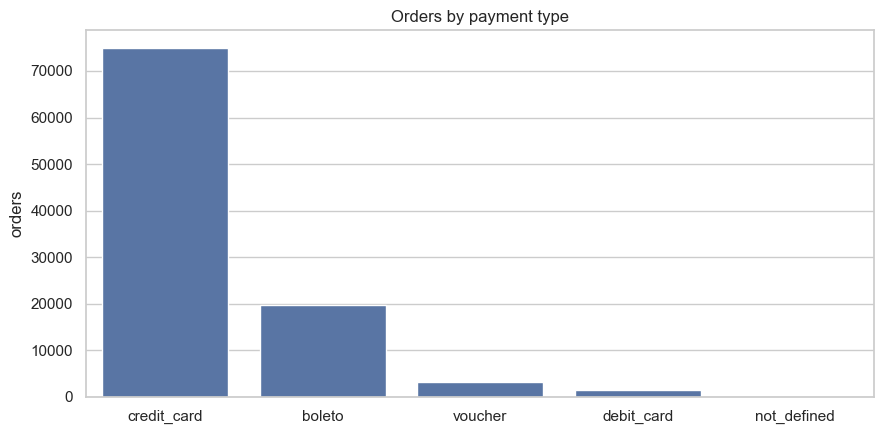

,type,orders,avg_installments,aov,order_share_pct
0,credit_card,74975,3.55,167.29,75.40
1,boleto,19784,1.00,145.03,19.90
2,voucher,3151,1.14,120.29,3.20
3,debit_card,1527,1.00,142.72,1.50
4,not_defined,3,1.00,0.00,0.00


In [14]:
pay = q('''
    select primary_payment_type as type, count(*) as orders,
           avg(installments) as avg_installments,
           avg(total_payment_value) as aov
    from dev_marts.fct_orders
    where primary_payment_type is not null and total_payment_value is not null
    group by 1 order by 2 desc
''')
pay["order_share_pct"] = (100 * pay["orders"] / pay["orders"].sum()).round(1)

fig, ax = plt.subplots()
sns.barplot(data=pay, x="type", y="orders", ax=ax, color="#4C72B0")
ax.set_title("Orders by payment type"); ax.set_xlabel(""); ax.set_ylabel("orders")
plt.tight_layout(); plt.show()
pay

**Interpretation.** **Credit card dominates (~75%)** and is the only method with meaningful
instalment use (**~3.6 instalments on average**), whereas boleto (~20%) is always paid in one lump.
Credit-card orders also carry a **higher average order value** (R$167 vs R$145 for boleto) — instalments
let customers commit to larger baskets. The `not_defined`/null rows are a tiny handful (documented as a
known data-quality issue in the dbt layer).

## 9. Customer satisfaction (reviews)

`review_score` is a 1–5 rating left after the order. We look at the distribution and, crucially, test
the hypothesis that **late delivery drives low scores**.

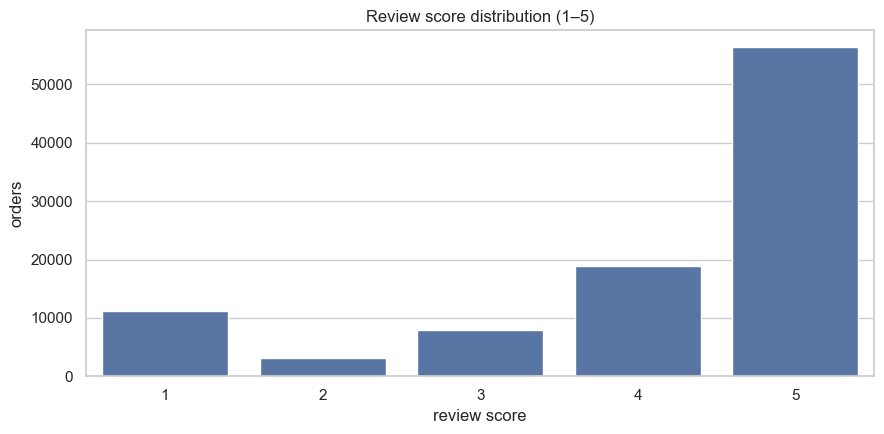

,review_score,n,pct
0,1,11113,11.40
1,2,3070,3.10
2,3,7999,8.20
3,4,18856,19.30
4,5,56427,57.90


In [15]:
rev = q('''
    select review_score, count(*) as n
    from dev_marts.fct_orders
    where review_score is not null
    group by 1 order by 1
''')
fig, ax = plt.subplots()
sns.barplot(data=rev, x="review_score", y="n", ax=ax, color="#4C72B0")
ax.set_title("Review score distribution (1–5)"); ax.set_xlabel("review score"); ax.set_ylabel("orders")
plt.tight_layout(); plt.show()
rev["pct"] = (100 * rev["n"] / rev["n"].sum()).round(1)
rev

In [16]:
rev_ontime = q('''
    select is_delivered_on_time, avg(review_score) as avg_score, count(*) as n
    from dev_marts.fct_orders
    where review_score is not null and is_delivered_on_time is not null and status = 'delivered'
    group by 1 order by 1
''')
rev_ontime

,is_delivered_on_time,avg_score,n
0,False,2.57,7566
1,True,4.30,87146


**Interpretation.** Scores are **bimodal, skewed positive**: ~58% are 5-star, but 1-star is the
second-largest bucket (~11%) — customers rate when delighted *or* burned. The delivery split is the
headline finding of this notebook:

> **On-time orders average 4.30★; late orders average 2.57★** — a **1.7-point** collapse.

Late delivery is the single clearest satisfaction killer in the data. This is the strongest candidate
for a deeper driver analysis (Section 12).

**⚠️ Confidence note.** This is a correlation, not a controlled test — late orders may differ in other
ways (heavier items, remote states). Section 12 lists the controls a proper driver model would add.

## 10. Customer behaviour — repeat rate & spend concentration

Using `mart_customer_summary` (one row per customer). Two questions: do customers come back, and how
concentrated is spend?

In [17]:
cust = q('''
    select avg(iff(is_repeat_customer, 1, 0)) * 100 as repeat_pct,
           avg(total_spend)    as avg_spend,
           median(total_spend) as median_spend,
           count(*)            as customers
    from dev_marts.mart_customer_summary
''')
cust

,repeat_pct,avg_spend,median_spend,customers
0,3.12,166.59,108.00,96096


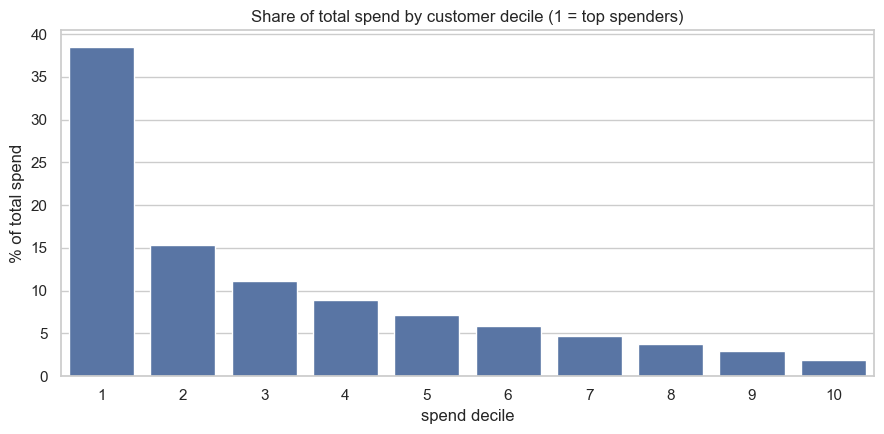

Top decile holds 38.5% of spend


,total_orders,customers
0,1,93099
1,2,2745
2,3,203
3,4,30
4,5,8


In [18]:
orders_per_cust = q('''
    select total_orders, count(*) as customers
    from dev_marts.mart_customer_summary
    group by 1 order by 1
''')

# Spend concentration: share of total spend held by each decile (decile 1 = top spenders)
conc = q('''
    with r as (
        select total_spend, ntile(10) over (order by total_spend desc) as decile
        from dev_marts.mart_customer_summary
    )
    select decile, sum(total_spend) as spend
    from r group by 1 order by 1
''')
conc["spend_share_pct"] = (100 * conc["spend"] / conc["spend"].sum()).round(1)

fig, ax = plt.subplots()
sns.barplot(data=conc, x="decile", y="spend_share_pct", ax=ax, color="#4C72B0")
ax.set_title("Share of total spend by customer decile (1 = top spenders)")
ax.set_xlabel("spend decile"); ax.set_ylabel("% of total spend")
plt.tight_layout(); plt.show()
print(f"Top decile holds {conc.loc[conc['decile']==1,'spend_share_pct'].iloc[0]}% of spend")
orders_per_cust.head()

**Interpretation.** Olist is an **acquisition-driven, one-and-done marketplace**: only **~3.1% of
customers ever place a second order** — ~93,100 of 96,100 customers bought exactly once. Spend is
moderately concentrated (top decile ≈ **38%** of revenue) but far less extreme than the *seller* side
(next section), because almost everyone is a single-purchase customer with a similar basket.

**⚠️ Confidence note — identity resolution.** Repeat-rate accuracy depends entirely on how customers
are de-duplicated. Olist's raw `customer_id` is *per-order*; a stable person is `customer_unique_id`.
This mart resolves to ~96,100 distinct customers from 99,441 orders, so some resolution is applied —
but the exact repeat rate is only as good as that mapping. Worth confirming in the dbt model before
publishing the number externally.

## 11. Seller performance

Using `mart_seller_performance` (one row per seller). Marketplaces typically show a power-law: a few
sellers drive most volume. We test that and check whether bigger sellers deliver better.

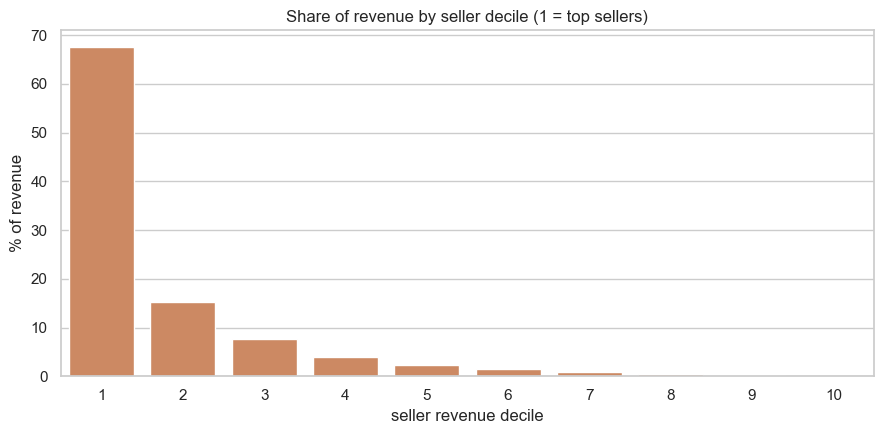

Top 10% of sellers = 67.6% of revenue


In [19]:
seller_conc = q('''
    with r as (
        select total_revenue, ntile(10) over (order by total_revenue desc) as decile
        from dev_marts.mart_seller_performance
    )
    select decile, sum(total_revenue) as revenue
    from r group by 1 order by 1
''')
seller_conc["rev_share_pct"] = (100 * seller_conc["revenue"] / seller_conc["revenue"].sum()).round(1)

fig, ax = plt.subplots()
sns.barplot(data=seller_conc, x="decile", y="rev_share_pct", ax=ax, color="#DD8452")
ax.set_title("Share of revenue by seller decile (1 = top sellers)")
ax.set_xlabel("seller revenue decile"); ax.set_ylabel("% of revenue")
plt.tight_layout(); plt.show()
print(f"Top 10% of sellers = {seller_conc.loc[seller_conc['decile']==1,'rev_share_pct'].iloc[0]}% of revenue")

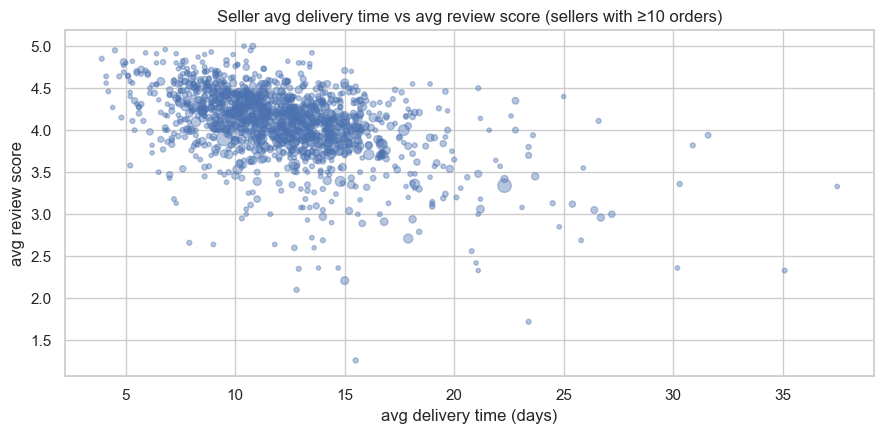

Correlation (delivery days vs review score): -0.468


In [20]:
# Do bigger / faster sellers get better reviews? Sample for a scatter.
sp = q('''
    select total_revenue, avg_delivery_time_days, on_time_delivery_rate, avg_review_score, total_orders
    from dev_marts.mart_seller_performance
    where avg_review_score is not null and avg_delivery_time_days is not null
      and total_orders >= 10          -- ignore tiny sellers whose averages are noisy
''')
fig, ax = plt.subplots()
sc = ax.scatter(sp["avg_delivery_time_days"], sp["avg_review_score"],
                s=np.sqrt(sp["total_orders"])*3, alpha=0.4, c="#4C72B0")
ax.set_title("Seller avg delivery time vs avg review score (sellers with ≥10 orders)")
ax.set_xlabel("avg delivery time (days)"); ax.set_ylabel("avg review score")
plt.tight_layout(); plt.show()
print("Correlation (delivery days vs review score):",
      round(sp["avg_delivery_time_days"].corr(sp["avg_review_score"]), 3))

**Interpretation.** The seller side is a **classic power-law**: the **top 10% of ~3,095 sellers
generate ~68% of revenue**, and the bottom half is negligible. The scatter reinforces Section 9 at the
seller level — sellers with **slower average delivery trend toward lower review scores** (negative
correlation). Delivery speed is a seller-quality lever, not just a logistics stat.

## 12. Findings & analysis backlog

### What the data says
1. **Growth business, ~97% delivered.** Volume ~4× from early-2017 to 2018; Nov-2017 Black-Friday
   spike. Reliable window is **Jan 2017 – Aug 2018** (edges are data-cutoff artefacts).
2. **Delivery reliability is the satisfaction lever.** ~92% on-time; on-time orders average **4.30★**
   vs **2.57★** for late — a 1.7-point swing. Confirmed again at the seller level.
3. **Under-promise / over-deliver logistics.** Orders arrive ~12 days *earlier* than the checkout
   estimate on average — estimates are conservative, not tight SLAs.
4. **Heavy geographic concentration.** São Paulo ≈ 42% of orders; the Southeast dominates. National
   averages are effectively SP averages.
5. **Broad category revenue, mild Pareto.** No single category >9%; ~17 of 72 categories = 80% revenue.
6. **Credit card + instalments culture.** ~75% credit card, ~3.6 instalments avg, higher AOV than the
   single-lump boleto (~20%).
7. **One-and-done customers, power-law sellers.** ~3% customer repeat rate (acquisition-driven);
   top 10% of sellers = ~68% of revenue.

### Analysis backlog — what to build next (candidates to prioritise together)
| # | Analysis | Builds on | Why it matters |
|---|---|---|---|
| A | **Delivery-lateness driver model** — quantify review-score impact of lateness, *controlling* for distance/state, item weight, category | §5, §9, §11 | Turn the headline correlation into a defensible, controlled finding |
| B | **Estimate-accuracy / SLA analysis** — where and by how much are estimates off? Which routes are chronically late? | §5 | Actionable logistics insight; ties lateness to geography |
| C | **RFM segmentation** (Recency, Frequency, Monetary) | §10 | Standard e-commerce segmentation; showcases analytics-engineering |
| D | **Geographic delivery equity** — delivery time & on-time rate by state / seller→customer distance | §6, §11 | Explains *why* some regions are late; joins `dim_geolocation` |
| E | **Category deep-dive** — freight-as-margin-proxy *by category and weight* (this notebook shows only the overall trend) | §7 | Freight ≈ 16–18% of price and drifting up, corr(weight, freight)=0.61 — margin story |
| F | **Cohort / retention view** *(caveated)* — monthly acquisition cohorts | §4, §10 | With ~3% repeat, the honest finding is "retention is near-zero" — still worth showing |

**Recommended next notebook:** start with **A + B + D** — they all revolve around the strongest,
most defensible signal in the data (delivery reliability → satisfaction) and naturally pull in the
geolocation and seller marts. RFM (C) is the best standalone analytics-engineering showcase after that.

*Next step: pick the priorities from this backlog and I'll build `02_*.ipynb` the same way.*